# 🏆 Football Goal Prediction — Domain Split M/W

Versi notebook ini memisahkan pipeline menjadi dua domain:
- **Men (M)**
- **Women (W)**

Tujuannya adalah menghindari pencampuran histori antar-domain, melatih model yang lebih spesifik,
lalu **menggabungkan kembali prediksi akhir** menjadi satu submission final.


## 1. Setup & Import Library

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb

from sklearn.linear_model import PoissonRegressor  
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb
import xgboost as xgb

pd.set_option('display.max_columns', 60)
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Data

In [20]:
from pathlib import Path

def resolve_existing_path(candidates):
    for p in candidates:
        if Path(p).exists():
            return str(Path(p))
    raise FileNotFoundError(f'Tidak menemukan file pada kandidat path: {candidates}')

train_path = resolve_existing_path([
    './dataset/train.csv',
    '/mnt/data/train.csv',
])

test_path = resolve_existing_path([
    './dataset/test.csv',
    '/mnt/data/test.csv',
])

gt_path = resolve_existing_path([
    './dataset/ground_truth_bersih.csv',
    './dataset/test_with_groundtruth.csv',
    '/mnt/data/test_with_groundtruth.csv',
])

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)
gt    = pd.read_csv(gt_path)

print(f'Using train path: {train_path}')
print(f'Using test  path: {test_path}')
print(f'Using gt    path: {gt_path}')

print(f'\nTrain : {train.shape}')
print(f'Test  : {test.shape}')
print(f'GT    : {gt.shape}')

train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

print(f'\nTrain date range: {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Test  date range: {test["date"].min().date()} → {test["date"].max().date()}')
train.head(3)

Using train path: dataset\train.csv
Using test  path: dataset\test.csv
Using gt    path: dataset\ground_truth_bersih.csv

Train : (78772, 47)
Test  : (42422, 20)
GT    : (42422, 3)

Train date range: 1872-11-30 → 2011-08-04
Test  date range: 2011-08-06 → 2026-03-31


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,rank_missing_team,rank_missing_opp,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,0,0,NaN,1.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,0.0,0.0,NaN,0.0,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,4,2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,98.0,98.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
from collections import defaultdict, deque

def _pts(g, c):
    return 3 if g > c else (1 if g == c else 0)

def build_fresh_test_rolling_domain(train_df, test_df, pred_df=None, domain_col='gender'):
    """
    Domain-aware rolling untuk test TANPA ground truth.

    Mode:
    - pred_df=None:
        pre-match rolling, state hanya dibangun dari train
    - pred_df ada:
        pseudo-fresh rolling, state test ikut di-update memakai prediksi sendiri

    pred_df wajib punya kolom:
    ['Id', 'pred_team_goals', 'pred_opp_goals']
    """
    tr = train_df.copy()
    te = test_df.copy()

    tr['date'] = pd.to_datetime(tr['date'])
    te['date'] = pd.to_datetime(te['date'])

    tr = tr.sort_values(['date', 'match_id', 'team']).reset_index(drop=True)
    te = te.sort_values(['date', 'match_id', 'team']).reset_index(drop=True)

    team_hist = defaultdict(lambda: deque(maxlen=10))
    h2h_hist  = defaultdict(lambda: deque(maxlen=5))
    last_dt   = {}
    elo_st    = {}
    rank_st   = {}

    print('Replaying training history with domain-aware state...', end=' ')
    for _, r in tr.iterrows():
        dom = r[domain_col]
        t, o = r['team'], r['opponent']
        g, c = r['team_goals'], r['opp_goals']

        t_key = (dom, t)
        o_key = (dom, o)
        p_key = (dom, t, o)

        team_hist[t_key].append((g, c, _pts(g, c)))
        h2h_hist[p_key].append((_pts(g, c), g - c))
        last_dt[t_key] = r['date']

        elo_st[t_key]  = r['elo_team'] if ('elo_team' in r and pd.notna(r['elo_team'])) else elo_st.get(t_key, 1500)
        rank_st[t_key] = r['rank_team'] if 'rank_team' in r else rank_st.get(t_key, np.nan)
    print('Done.')

    pred_map = {}
    if pred_df is not None:
        tmp = pred_df[['Id', 'pred_team_goals', 'pred_opp_goals']].copy()
        pred_map = {
            row['Id']: (float(row['pred_team_goals']), float(row['pred_opp_goals']))
            for _, row in tmp.iterrows()
        }

    fresh = {}

    print('Computing domain-aware rolling features for test...', end=' ')
    for mid, grp in te.groupby('match_id', sort=False):
        rows = list(grp.iterrows())

        # ambil fitur PRE-MATCH untuk semua row di match ini
        for idx, r in rows:
            dom = r[domain_col]
            t, o = r['team'], r['opponent']

            t_key = (dom, t)
            o_key = (dom, o)
            p_key = (dom, t, o)

            th5  = list(team_hist[t_key])[-5:]
            th10 = list(team_hist[t_key])[-10:]
            oh5  = list(team_hist[o_key])[-5:]
            oh10 = list(team_hist[o_key])[-10:]
            ph   = list(h2h_hist[p_key])

            sm  = lambda lst, i: float(np.mean([x[i] for x in lst])) if lst else np.nan
            ss  = lambda lst, i: float(sum(x[i] for x in lst)) if lst else np.nan
            wr  = lambda lst: sum(1 for x in lst if x[2] == 3) / len(lst) if lst else np.nan
            gdf = lambda lst: (ss(lst, 0) - ss(lst, 1)) if lst else np.nan

            fresh[idx] = {
                'team_points_last5': ss(th5, 2),
                'team_points_last10': ss(th10, 2),
                'team_gd_last5': gdf(th5),
                'team_avg_goals_last5': sm(th5, 0),
                'team_avg_conceded_last5': sm(th5, 1),
                'team_win_rate_last10': wr(th10),

                'opp_points_last5': ss(oh5, 2),
                'opp_points_last10': ss(oh10, 2),
                'opp_gd_last5': gdf(oh5),
                'opp_avg_goals_last5': sm(oh5, 0),
                'opp_avg_conceded_last5': sm(oh5, 1),
                'opp_win_rate_last10': wr(oh10),

                'h2h_points_last5': ss(ph, 0),
                'h2h_gd_last5': ss(ph, 1) if ph else np.nan,

                'days_since_last_match_team': (r['date'] - last_dt[t_key]).days if t_key in last_dt else np.nan,
                'days_since_last_match_opp': (r['date'] - last_dt[o_key]).days if o_key in last_dt else np.nan,

                'elo_team': elo_st.get(t_key, 1500),
                'elo_opponent': elo_st.get(o_key, 1500),
                'rank_team': rank_st.get(t_key, np.nan),
                'rank_opponent': rank_st.get(o_key, np.nan),
            }

        # kalau ada prediksi, update state setelah match selesai
        if pred_df is not None and rows:
            _, r0 = rows[0]

            if r0['Id'] in pred_map:
                dom = r0[domain_col]
                t, o = r0['team'], r0['opponent']

                g_hat, c_hat = pred_map[r0['Id']]
                g_hat = int(np.clip(np.rint(g_hat), 0, 10))
                c_hat = int(np.clip(np.rint(c_hat), 0, 10))

                t_key = (dom, t)
                o_key = (dom, o)

                team_hist[t_key].append((g_hat, c_hat, _pts(g_hat, c_hat)))
                team_hist[o_key].append((c_hat, g_hat, _pts(c_hat, g_hat)))

                h2h_hist[(dom, t, o)].append((_pts(g_hat, c_hat), g_hat - c_hat))
                h2h_hist[(dom, o, t)].append((_pts(c_hat, g_hat), c_hat - g_hat))

                last_dt[t_key] = r0['date']
                last_dt[o_key] = r0['date']

                e_t, e_o = elo_st.get(t_key, 1500), elo_st.get(o_key, 1500)
                exp_t = 1 / (1 + 10 ** ((e_o - e_t) / 400))
                s = 1 if g_hat > c_hat else (0.5 if g_hat == c_hat else 0)

                elo_st[t_key] = e_t + 20 * (s - exp_t)
                elo_st[o_key] = e_o + 20 * ((1 - s) - (1 - exp_t))

    print('Done.')

    fresh_df = pd.DataFrame(fresh).T.reindex(te.index).astype(float)
    fresh_df.insert(0, 'Id', te['Id'].values)

    fresh_df['points_last5_diff'] = fresh_df['team_points_last5'] - fresh_df['opp_points_last5']
    fresh_df['gd_last5_diff'] = fresh_df['team_gd_last5'] - fresh_df['opp_gd_last5']
    fresh_df['rank_diff'] = fresh_df['rank_team'] - fresh_df['rank_opponent']
    fresh_df['rank_missing_team'] = fresh_df['rank_team'].isna().astype(float)
    fresh_df['rank_missing_opp'] = fresh_df['rank_opponent'].isna().astype(float)

    return fresh_df


# INITIAL VERSION: dipakai setelah load data, murni train + test saja
test_fresh_rolling = build_fresh_test_rolling_domain(train, test, pred_df=None)

print(f'\nShape fresh rolling          : {test_fresh_rolling.shape}')
print(f'Non-null team_avg_goals_last5: {test_fresh_rolling["team_avg_goals_last5"].notna().mean():.1%}')
print(f'ELO mean fresh rolling       : {test_fresh_rolling["elo_team"].mean():.1f}')
print('\nDomain-aware fresh rolling stats built (train+test only) ✓')

Replaying training history with domain-aware state... Done.
Computing domain-aware rolling features for test... Done.

Shape fresh rolling          : (42422, 26)
Non-null team_avg_goals_last5: 96.8%
ELO mean fresh rolling       : 1580.0

Domain-aware fresh rolling stats built (train+test only) ✓


## 3. Exploratory Data Analysis

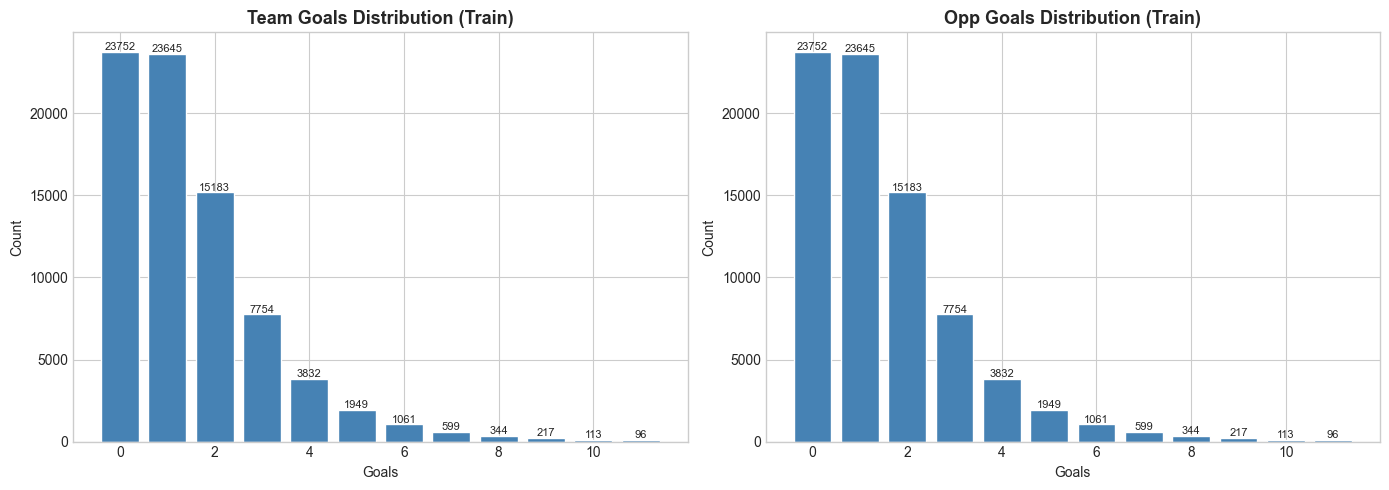

Mean goals  : 1.5631
Median goals: 1.0
Skewness    : 2.6398


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['team_goals', 'opp_goals'], ['Team Goals', 'Opp Goals']):
    counts = train[col].value_counts().sort_index().head(12)
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{title} Distribution (Train)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Goals'); ax.set_ylabel('Count')
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 100, str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Mean goals  : {train["team_goals"].mean():.4f}')
print(f'Median goals: {train["team_goals"].median()}')
print(f'Skewness    : {train["team_goals"].skew():.4f}')

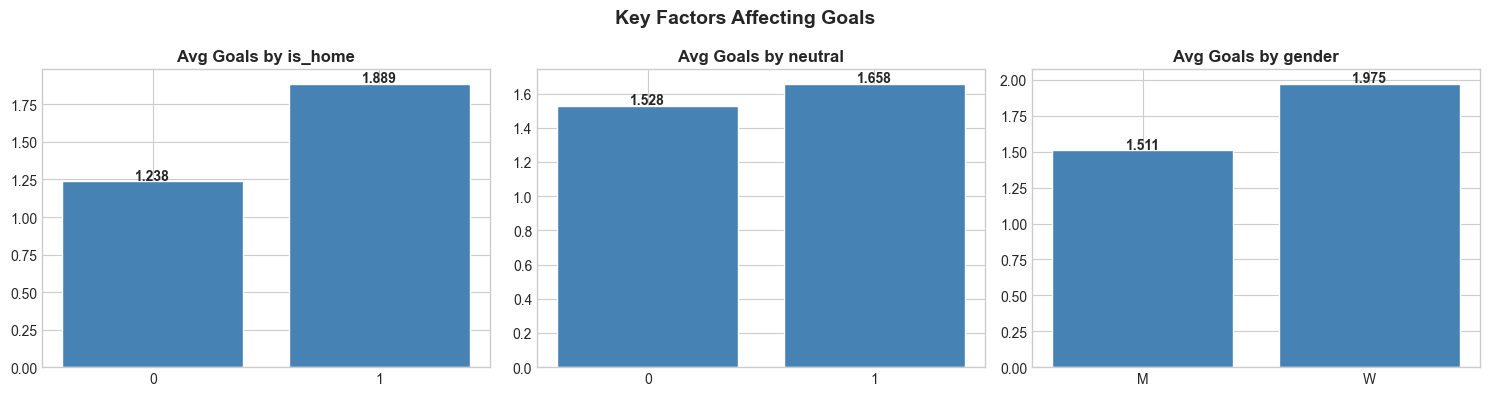

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['is_home', 'neutral', 'gender']):
    avg = train.groupby(col)['team_goals'].mean()
    ax.bar([str(i) for i in avg.index], avg.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Avg Goals by {col}', fontweight='bold')
    for i, v in enumerate(avg.values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.suptitle('Key Factors Affecting Goals', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

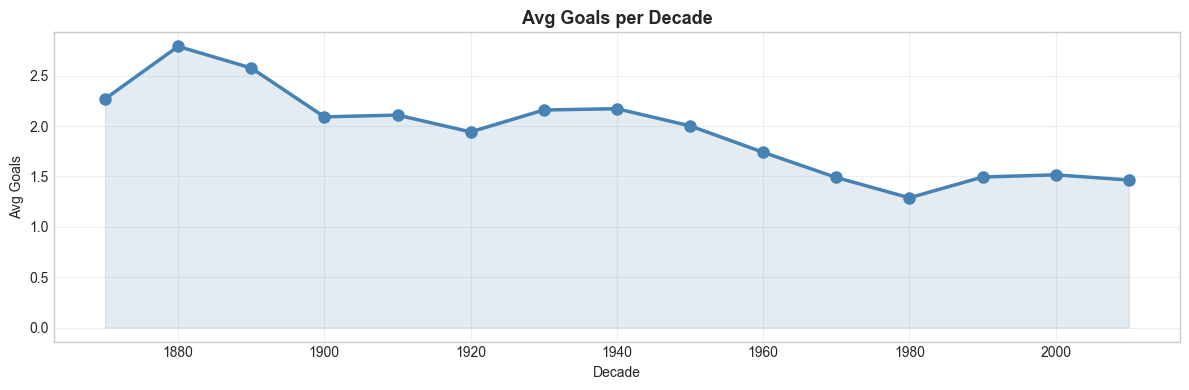

In [24]:
train['decade'] = (train['date'].dt.year // 10) * 10
decade_goals = train.groupby('decade')['team_goals'].mean()

plt.figure(figsize=(12, 4))
plt.plot(decade_goals.index, decade_goals.values, marker='o', linewidth=2.5,
         color='steelblue', markersize=8)
plt.fill_between(decade_goals.index, decade_goals.values, alpha=0.15, color='steelblue')
plt.title('Avg Goals per Decade', fontsize=13, fontweight='bold')
plt.xlabel('Decade'); plt.ylabel('Avg Goals'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Definisi Metrik Resmi AW-MAE

In [25]:
# ─── Tournament Weights ────────────────────────────────────────────────────
def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    if "friendly" in t:
        return 0.96
    return 1.20


# ─── Loss Constants ────────────────────────────────────────────────────────
EXACT_PENALTY            = 0.30
OUTCOME_PENALTY          = 0.25
GD_PENALTY               = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER          = 1.50


def _outcome(a: int, b: int) -> int:
    if a > b:  return  1
    if a < b:  return -1
    return 0


def official_match_loss(
    y_team_true, y_opp_true,
    y_team_pred, y_opp_pred,
):
    """Per-match loss sesuai formula resmi kompetisi."""
    y_team_true = np.asarray(y_team_true).astype(int)
    y_opp_true  = np.asarray(y_opp_true).astype(int)
    y_team_pred = np.asarray(y_team_pred).astype(int)
    y_opp_pred  = np.asarray(y_opp_pred).astype(int)

    base_mae = (
        np.abs(y_team_true - y_team_pred) +
        np.abs(y_opp_true  - y_opp_pred)
    ) / 2.0

    exact_hit    = (y_team_true == y_team_pred) & (y_opp_true == y_opp_pred)
    true_outcome = np.vectorize(_outcome)(y_team_true, y_opp_true)
    pred_outcome = np.vectorize(_outcome)(y_team_pred, y_opp_pred)
    outcome_hit  = (true_outcome == pred_outcome)
    gd_hit       = ((y_team_true - y_opp_true) == (y_team_pred - y_opp_pred))

    penalty = (
        (~exact_hit).astype(float)   * EXACT_PENALTY +
        (~outcome_hit).astype(float) * OUTCOME_PENALTY +
        (~gd_hit).astype(float)      * GD_PENALTY
    )

    raw_error = base_mae + penalty
    raw_error = np.where(outcome_hit, raw_error, raw_error * WRONG_OUTCOME_MULTIPLIER)

    return raw_error ** NONLINEAR_POWER


def awmae_score(
    y_team_true, y_opp_true,
    y_team_pred, y_opp_pred,
    weights=None,
) -> float:
    """Official AW-MAE: tournament-weighted average per-match loss."""
    losses = official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred)
    if weights is None:
        weights = np.ones(len(losses), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    return float(np.average(losses, weights=weights))


print('Official AW-MAE metric defined ✓')
print()
print('Tournament weight examples:')
for t in ['FIFA World Cup', 'AFC Asian Cup', 'Friendly', 'UEFA Euro qualification', 'Copa America']:
    print(f'  {t:<35} → weight = {get_tournament_weight(t):.2f}')

Official AW-MAE metric defined ✓

Tournament weight examples:
  FIFA World Cup                      → weight = 2.00
  AFC Asian Cup                       → weight = 1.80
  Friendly                            → weight = 0.96
  UEFA Euro qualification             → weight = 1.20
  Copa America                        → weight = 1.20


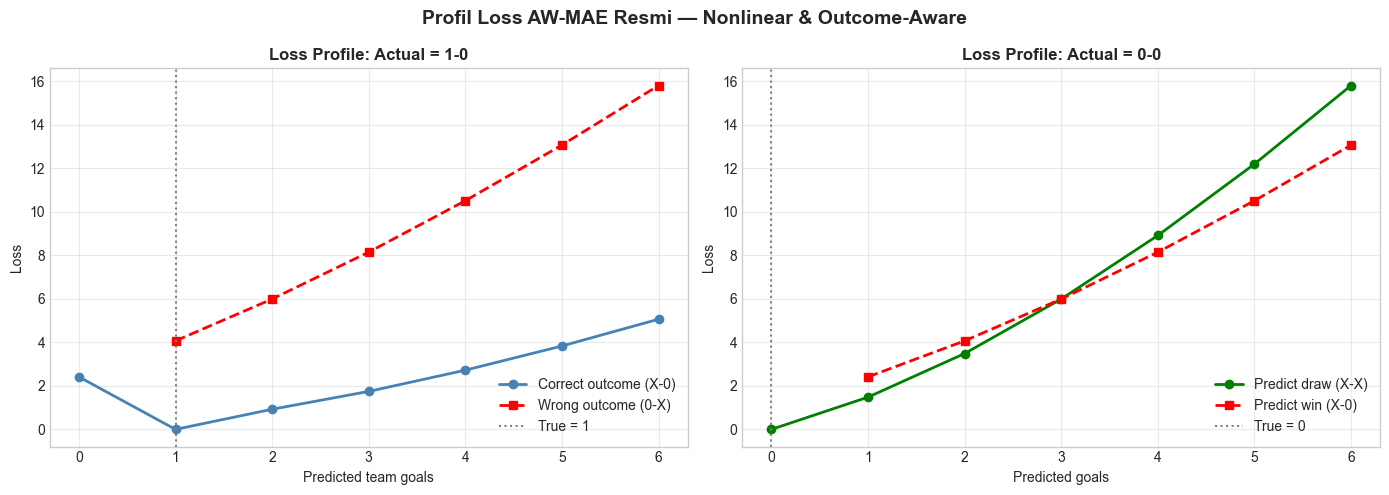

Actual    Predict     Loss      Keterangan
------------------------------------------------------------
1-0       1-0         0.0000    Exact ✓
1-0       2-0         0.9259    Right outcome, wrong score
1-0       2-1         1.4822    Right outcome, wrong score & GD
1-0       1-1         2.4150    Wrong outcome (draw)
1-0       0-1         4.0720    Wrong outcome (reversed!)
0-0       0-0         0.0000    Exact draw ✓
2-1       2-1         0.0000    Exact ✓
3-0       1-0         1.7460    Right outcome, different GD


In [26]:
# Visualisasi profil loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pred_range = list(range(0, 7))
losses_correct = [official_match_loss([1],[0],[p],[0])[0] for p in pred_range]
losses_wrong   = [official_match_loss([1],[0],[0],[p])[0] for p in pred_range]

axes[0].plot(pred_range, losses_correct, 'o-', color='steelblue', lw=2, label='Correct outcome (X-0)')
axes[0].plot(pred_range[1:], losses_wrong[1:], 's--', color='red', lw=2, label='Wrong outcome (0-X)')
axes[0].axvline(1, color='gray', ls=':', label='True = 1')
axes[0].set_title('Loss Profile: Actual = 1-0', fontweight='bold')
axes[0].set_xlabel('Predicted team goals'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

losses_draw  = [official_match_loss([0],[0],[p],[p])[0] for p in pred_range]
losses_ndraw = [official_match_loss([0],[0],[p],[0])[0] for p in pred_range]

axes[1].plot(pred_range, losses_draw, 'o-', color='green', lw=2, label='Predict draw (X-X)')
axes[1].plot(pred_range[1:], losses_ndraw[1:], 's--', color='red', lw=2, label='Predict win (X-0)')
axes[1].axvline(0, color='gray', ls=':', label='True = 0')
axes[1].set_title('Loss Profile: Actual = 0-0', fontweight='bold')
axes[1].set_xlabel('Predicted goals'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Profil Loss AW-MAE Resmi — Nonlinear & Outcome-Aware', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Tabel contoh loss
examples = [
    ('1-0', '1-0', 'Exact ✓'),
    ('1-0', '2-0', 'Right outcome, wrong score'),
    ('1-0', '2-1', 'Right outcome, wrong score & GD'),
    ('1-0', '1-1', 'Wrong outcome (draw)'),
    ('1-0', '0-1', 'Wrong outcome (reversed!)'),
    ('0-0', '0-0', 'Exact draw ✓'),
    ('2-1', '2-1', 'Exact ✓'),
    ('3-0', '1-0', 'Right outcome, different GD'),
]
print(f'{"Actual":<10}{"Predict":<12}{"Loss":<10}Keterangan')
print('-'*60)
for true_s, pred_s, note in examples:
    tt, ot = map(int, true_s.split('-'))
    tp, op = map(int, pred_s.split('-'))
    loss = official_match_loss([tt],[ot],[tp],[op])[0]
    print(f'{true_s:<10}{pred_s:<12}{loss:<10.4f}{note}')

## 5. Feature Engineering

In [27]:
TEAM_STATE_COLS = [
    'team_points_last5',
    'team_points_last10',
    'team_gd_last5',
    'team_avg_goals_last5',
    'team_avg_conceded_last5',
    'team_win_rate_last10',
    'elo_team',
    'rank_team',
    'rank_missing_team'
]

PAIR_STATE_COLS = [
    'h2h_points_last5',
    'h2h_gd_last5'
]


def add_time_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    df['year'] = df['date'].dt.year.astype(int)
    df['month'] = df['date'].dt.month.astype(int)
    df['quarter'] = df['date'].dt.quarter.astype(int)
    df['dayofweek'] = df['date'].dt.dayofweek.astype(int)
    df['dayofyear'] = df['date'].dt.dayofyear.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 366.0)
    df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 366.0)

    return df


def build_history_pack(train_df, domain_col='gender'):
    """
    Semua histori disimpan secara domain-aware agar team yang sama di M dan W
    tidak saling bocor / tercampur.
    """
    tr = add_time_features(train_df)
    tr = tr.sort_values(['date', 'match_id', 'team']).copy()

    latest_team = (
        tr.groupby([domain_col, 'team'], group_keys=False)
          .tail(1)[[domain_col, 'team', 'date'] + TEAM_STATE_COLS]
          .rename(columns={'date': 'last_team_date'})
          .reset_index(drop=True)
    )

    latest_pair = (
        tr.groupby([domain_col, 'team', 'opponent'], group_keys=False)
          .tail(1)[[domain_col, 'team', 'opponent', 'date'] + PAIR_STATE_COLS]
          .rename(columns={'date': 'last_h2h_date'})
          .reset_index(drop=True)
    )

    team_hist = (
        tr.groupby([domain_col, 'team'])
          .agg(
              team_hist_avg_goals=('team_goals', 'mean'),
              team_hist_avg_conceded=('opp_goals', 'mean'),
              team_hist_std_goals=('team_goals', 'std'),
              team_hist_matches=('match_id', 'nunique'),
          )
          .reset_index()
    )

    tournament_hist = (
        tr.groupby([domain_col, 'tournament'])
          .agg(
              tournament_avg_goals=('team_goals', 'mean'),
              tournament_avg_total=('team_goals', lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()),
          )
          .reset_index()
    )

    venue_hist = (
        tr.groupby([domain_col, 'venue_country'])
          .agg(
              venue_avg_goals=('team_goals', 'mean'),
              venue_avg_total=('team_goals', lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()),
          )
          .reset_index()
    )

    conf_hist = (
        tr.groupby([domain_col, 'confederation_team'])
          .agg(
              conf_team_avg_goals=('team_goals', 'mean'),
              conf_team_avg_conceded=('opp_goals', 'mean'),
          )
          .reset_index()
    )

    gender_hist = (
        tr.groupby([domain_col])
          .agg(
              gender_avg_goals=('team_goals', 'mean'),
              gender_avg_total=('team_goals', lambda s: (s + tr.loc[s.index, 'opp_goals']).mean()),
          )
          .reset_index()
    )

    return {
        'latest_team': latest_team,
        'latest_pair': latest_pair,
        'team_hist': team_hist,
        'tournament_hist': tournament_hist,
        'venue_hist': venue_hist,
        'conf_hist': conf_hist,
        'gender_hist': gender_hist,
    }


def engineer_features(df, train_df, history_pack, is_test=False, domain_col='gender'):
    d = add_time_features(df)
    d = d.copy()

    if 'altitude_venue' in d.columns:
        d['altitude_venue'] = d['altitude_venue'].replace(-9999, np.nan)

    d['tournament_weight'] = d['tournament'].apply(get_tournament_weight)

    if is_test:
        latest_team = history_pack['latest_team'].copy()

        d = d.merge(latest_team, on=[domain_col, 'team'], how='left')

        opp_latest = latest_team.rename(columns={
            'team': 'opponent',
            'last_team_date': 'last_opp_date',
            'team_points_last5': 'opp_points_last5',
            'team_points_last10': 'opp_points_last10',
            'team_gd_last5': 'opp_gd_last5',
            'team_avg_goals_last5': 'opp_avg_goals_last5',
            'team_avg_conceded_last5': 'opp_avg_conceded_last5',
            'team_win_rate_last10': 'opp_win_rate_last10',
            'elo_team': 'elo_opponent',
            'rank_team': 'rank_opponent',
            'rank_missing_team': 'rank_missing_opp',
        })
        d = d.merge(opp_latest, on=[domain_col, 'opponent'], how='left')

        latest_pair = history_pack['latest_pair'].copy()
        d = d.merge(latest_pair, on=[domain_col, 'team', 'opponent'], how='left')

        d['days_since_last_match_team'] = (d['date'] - d['last_team_date']).dt.days
        d['days_since_last_match_opp'] = (d['date'] - d['last_opp_date']).dt.days

        d['points_last5_diff'] = d['team_points_last5'] - d['opp_points_last5']
        d['points_last10_diff'] = d['team_points_last10'] - d['opp_points_last10']
        d['gd_last5_diff'] = d['team_gd_last5'] - d['opp_gd_last5']
        d['rank_diff'] = d['rank_team'] - d['rank_opponent']

    d = d.merge(history_pack['team_hist'], on=[domain_col, 'team'], how='left')

    opp_team_hist = history_pack['team_hist'].rename(columns={
        'team': 'opponent',
        'team_hist_avg_goals': 'opp_hist_avg_goals',
        'team_hist_avg_conceded': 'opp_hist_avg_conceded',
        'team_hist_std_goals': 'opp_hist_std_goals',
        'team_hist_matches': 'opp_hist_matches',
    })
    d = d.merge(opp_team_hist, on=[domain_col, 'opponent'], how='left')

    d = d.merge(history_pack['tournament_hist'], on=[domain_col, 'tournament'], how='left')
    d = d.merge(history_pack['venue_hist'], on=[domain_col, 'venue_country'], how='left')
    d = d.merge(history_pack['conf_hist'], on=[domain_col, 'confederation_team'], how='left')
    d = d.merge(history_pack['gender_hist'], on=[domain_col], how='left')

    d['elo_diff'] = d['elo_team'] - d['elo_opponent']
    d['elo_sum'] = d['elo_team'] + d['elo_opponent']
    d['elo_gap_abs'] = np.abs(d['elo_diff'])

    d['rank_gap_abs'] = np.abs(d['rank_diff'])

    d['rest_diff'] = d['days_since_last_match_team'] - d['days_since_last_match_opp']
    d['rest_sum'] = d['days_since_last_match_team'] + d['days_since_last_match_opp']

    d['goal_form_diff'] = d['team_avg_goals_last5'] - d['opp_avg_goals_last5']
    d['conceded_form_diff'] = d['team_avg_conceded_last5'] - d['opp_avg_conceded_last5']
    d['attack_vs_defense'] = d['team_avg_goals_last5'] - d['opp_avg_conceded_last5']
    d['defense_vs_attack'] = d['opp_avg_goals_last5'] - d['team_avg_conceded_last5']

    d['winrate_diff'] = d['team_win_rate_last10'] - d['opp_win_rate_last10']
    d['h2h_strength'] = d['h2h_points_last5'] + 0.25 * d['h2h_gd_last5']

    d['same_confederation'] = (d['confederation_team'] == d['confederation_opp']).astype(int)
    d['major_tournament'] = (d['tournament_weight'] >= 1.8).astype(int)

    d['home_x_elo'] = d['is_home'] * d['elo_diff']
    d['neutral_x_elo'] = d['neutral'] * d['elo_diff']

    d['travel_diff'] = d['distance_travel_team'] - d['distance_travel_opp']
    d['population_diff'] = d['population_team'] - d['population_opp']
    d['gdp_diff'] = d['gdp_per_capita_team'] - d['gdp_per_capita_opp']
    d['temperature_home_interaction'] = d['temperature_venue'] * d['is_home']

    for col in [
        'population_team', 'population_opp',
        'gdp_per_capita_team', 'gdp_per_capita_opp',
        'distance_travel_team', 'distance_travel_opp'
    ]:
        if col in d.columns:
            d[f'log1p_{col}'] = np.log1p(np.clip(d[col], a_min=0, a_max=None))

    return d


print('Feature engineering V3 (domain-aware history) ready ✓')

Feature engineering V3 (domain-aware history) ready ✓


In [28]:
EXCLUDE = [
    'Id', 'match_id', 'date',
    'team', 'opponent',
    'venue_country', 'tournament',
    'gender', 'confederation_team', 'confederation_opp',
    'team_goals', 'opp_goals',
    'last_team_date', 'last_opp_date', 'last_h2h_date'
]

DOMAIN_VALUES = ['M', 'W']

def prepare_domain_features(train_all, test_all, test_fresh_all, domain_value):
    train_dom = train_all[train_all['gender'] == domain_value].copy().reset_index(drop=True)
    test_dom  = test_all[test_all['gender'] == domain_value].copy().reset_index(drop=True)
    fresh_dom = test_fresh_all.merge(
        test_all[['Id', 'gender']],
        on='Id',
        how='left',
        validate='one_to_one'
    )
    fresh_dom = fresh_dom[fresh_dom['gender'] == domain_value].copy().drop(columns=['gender']).reset_index(drop=True)

    history_pack = build_history_pack(train_dom)

    train_fe = engineer_features(train_dom, train_dom, history_pack, is_test=False).reset_index(drop=True)
    test_fe  = engineer_features(test_dom,  train_dom, history_pack, is_test=True).reset_index(drop=True)

    common_cols = [
        c for c in train_fe.columns
        if c in test_fe.columns and c not in EXCLUDE
    ]

    feature_cols = [
        c for c in common_cols
        if pd.api.types.is_numeric_dtype(train_fe[c]) and pd.api.types.is_numeric_dtype(test_fe[c])
    ]
    feature_cols = sorted(feature_cols)

    fresh_cols = [c for c in fresh_dom.columns if c != 'Id']
    fresh_map = fresh_dom.set_index('Id')

    print(f'Applying fresh rolling stats to domain={domain_value} ...')
    for col in fresh_cols:
        if col in test_fe.columns:
            test_fe[col] = test_fe['Id'].map(fresh_map[col])

    for df_ in [train_fe, test_fe]:
        if 'elo_team' in df_.columns and 'elo_opponent' in df_.columns:
            df_['elo_diff'] = df_['elo_team'] - df_['elo_opponent']
            df_['elo_sum'] = df_['elo_team'] + df_['elo_opponent']
            df_['elo_gap_abs'] = np.abs(df_['elo_diff'])
        if 'rank_diff' in df_.columns:
            df_['rank_gap_abs'] = np.abs(df_['rank_diff'])
        if 'team_avg_goals_last5' in df_.columns and 'opp_avg_goals_last5' in df_.columns:
            df_['goal_form_diff'] = df_['team_avg_goals_last5'] - df_['opp_avg_goals_last5']
        if 'team_avg_conceded_last5' in df_.columns and 'opp_avg_conceded_last5' in df_.columns:
            df_['conceded_form_diff'] = df_['team_avg_conceded_last5'] - df_['opp_avg_conceded_last5']
            df_['attack_vs_defense'] = df_['team_avg_goals_last5'] - df_['opp_avg_conceded_last5']
            df_['defense_vs_attack'] = df_['opp_avg_goals_last5'] - df_['team_avg_conceded_last5']
        if 'team_win_rate_last10' in df_.columns and 'opp_win_rate_last10' in df_.columns:
            df_['winrate_diff'] = df_['team_win_rate_last10'] - df_['opp_win_rate_last10']
        if 'h2h_points_last5' in df_.columns and 'h2h_gd_last5' in df_.columns:
            df_['h2h_strength'] = df_['h2h_points_last5'] + 0.25 * df_['h2h_gd_last5']
        if 'is_home' in df_.columns and 'elo_diff' in df_.columns:
            df_['home_x_elo'] = df_['is_home'] * df_['elo_diff']
        if 'neutral' in df_.columns and 'elo_diff' in df_.columns:
            df_['neutral_x_elo'] = df_['neutral'] * df_['elo_diff']
        if 'days_since_last_match_team' in df_.columns and 'days_since_last_match_opp' in df_.columns:
            df_['rest_diff'] = df_['days_since_last_match_team'] - df_['days_since_last_match_opp']
            df_['rest_sum'] = df_['days_since_last_match_team'] + df_['days_since_last_match_opp']

    train_fe[feature_cols] = train_fe[feature_cols].replace([np.inf, -np.inf], np.nan)
    test_fe[feature_cols]  = test_fe[feature_cols].replace([np.inf, -np.inf], np.nan)

    fill_map = train_fe[feature_cols].median(numeric_only=True)
    train_fe[feature_cols] = train_fe[feature_cols].fillna(fill_map)
    test_fe[feature_cols]  = test_fe[feature_cols].fillna(fill_map)

    date_min = train_fe['date'].min()
    date_max = train_fe['date'].max()
    span_days = max((date_max - date_min).days, 1)

    train_fe['recency_weight'] = 0.70 + 0.30 * (
        (train_fe['date'] - date_min).dt.days / span_days
    )
    train_fe['fit_weight'] = train_fe['tournament_weight'] * train_fe['recency_weight']

    print(f'[{domain_value}] train shape   : {train_fe.shape}')
    print(f'[{domain_value}] test shape    : {test_fe.shape}')
    print(f'[{domain_value}] feature count : {len(feature_cols)}')

    preview_cols = [
        c for c in [
            'team_points_last5', 'opp_points_last5', 'points_last5_diff',
            'team_points_last10', 'opp_points_last10', 'points_last10_diff',
            'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff',
            'team_avg_goals_last5', 'opp_avg_goals_last5',
            'team_avg_conceded_last5', 'opp_avg_conceded_last5',
            'elo_team', 'elo_opponent', 'elo_diff',
            'rank_team', 'rank_opponent', 'rank_diff',
            'days_since_last_match_team', 'days_since_last_match_opp', 'rest_diff',
            'h2h_points_last5', 'h2h_gd_last5', 'h2h_strength',
            'goal_form_diff', 'attack_vs_defense',
            'tournament_weight', 'major_tournament'
        ] if c in feature_cols
    ]
    print(f'[{domain_value}] preview features: {preview_cols[:15]}{" ..." if len(preview_cols) > 15 else ""}')

    return {
        'domain': domain_value,
        'history_pack': history_pack,
        'train_fe': train_fe,
        'test_fe': test_fe,
        'feature_cols': feature_cols,
        'fill_map': fill_map,
    }


domain_data = {
    dom: prepare_domain_features(train, test, test_fresh_rolling, dom)
    for dom in DOMAIN_VALUES
}

domain_summary = pd.DataFrame({
    dom: {
        'train_rows': len(domain_data[dom]['train_fe']),
        'test_rows': len(domain_data[dom]['test_fe']),
        'n_features': len(domain_data[dom]['feature_cols']),
    }
    for dom in DOMAIN_VALUES
}).T

display(domain_summary)

Applying fresh rolling stats to domain=M ...
[M] train shape   : (69966, 105)
[M] test shape    : (28464, 104)
[M] feature count : 90
[M] preview features: ['team_points_last5', 'opp_points_last5', 'points_last5_diff', 'team_points_last10', 'opp_points_last10', 'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff', 'team_avg_goals_last5', 'opp_avg_goals_last5', 'team_avg_conceded_last5', 'opp_avg_conceded_last5', 'elo_team', 'elo_opponent', 'elo_diff'] ...
Applying fresh rolling stats to domain=W ...
[W] train shape   : (8806, 105)
[W] test shape    : (13958, 104)
[W] feature count : 90
[W] preview features: ['team_points_last5', 'opp_points_last5', 'points_last5_diff', 'team_points_last10', 'opp_points_last10', 'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff', 'team_avg_goals_last5', 'opp_avg_goals_last5', 'team_avg_conceded_last5', 'opp_avg_conceded_last5', 'elo_team', 'elo_opponent', 'elo_diff'] ...


,train_rows,test_rows,n_features
M,69966,28464,90
W,8806,13958,90


## 6. Pemodelan ML — Domain-Specific Ensemble (M dan W)

Mulai dari bagian ini, model dilatih **terpisah untuk domain M dan W**.
Setelah itu prediksi digabung kembali berdasarkan `Id`.


In [29]:
lgb_params = dict(
    objective='poisson',
    n_estimators=4000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=25,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=SEED,
    verbose=-1
)

xgb_params = dict(
    objective='count:poisson',
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.25,
    reg_lambda=1.5,
    gamma=0.05,
    random_state=SEED,
    tree_method='hist',
    eval_metric='mae',
    verbosity=0
)

from catboost import CatBoostRegressor

cat_params = dict(
    loss_function='Poisson',
    iterations=3000,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=3.0,
    min_data_in_leaf=25,
    subsample=0.85,
    colsample_bylevel=0.85,
    random_seed=SEED,
    verbose=0,
    allow_writing_files=False,
)

print('Domain model params ready ✓')
for dom in DOMAIN_VALUES:
    X_shape = domain_data[dom]['train_fe'][domain_data[dom]['feature_cols']].shape
    Xtest_shape = domain_data[dom]['test_fe'][domain_data[dom]['feature_cols']].shape
    print(f'[{dom}] X shape      : {X_shape}')
    print(f'[{dom}] X_test shape : {Xtest_shape}')

Domain model params ready ✓
[M] X shape      : (69966, 90)
[M] X_test shape : (28464, 90)
[W] X shape      : (8806, 90)
[W] X_test shape : (13958, 90)


In [30]:
def build_temporal_match_folds(df, n_splits=5, holdout_start_frac=0.55):
    """
    Validation hanya di bagian akhir timeline.
    Train fold selalu strictly sebelum validation fold.
    Dua row dari match yang sama selalu satu fold.
    """
    meta = (
        df[['match_id', 'date']]
        .drop_duplicates()
        .sort_values('date')
        .reset_index(drop=True)
    )

    start_idx = int(len(meta) * holdout_start_frac)
    eval_meta = meta.iloc[start_idx:].copy()

    blocks = np.array_split(eval_meta.index.to_numpy(), n_splits)
    folds = []

    for block in blocks:
        val_meta = meta.loc[block].copy()
        val_start = val_meta['date'].min()
        val_ids = set(val_meta['match_id'])

        tr_idx = df.index[df['date'] < val_start].to_numpy()
        val_idx = df.index[df['match_id'].isin(val_ids)].to_numpy()

        folds.append((tr_idx, val_idx))

    return folds


def enforce_match_consistency(df_rows, team_pred, opp_pred):
    """
    Karena 1 match muncul 2 baris, paksa prediksi simetris:
    row A pred (a,b), row B pred (b,a)
    """
    team_pred = np.asarray(team_pred, dtype=float)
    opp_pred = np.asarray(opp_pred, dtype=float)

    team_adj = team_pred.copy()
    opp_adj = opp_pred.copy()

    groups = df_rows.groupby('match_id').groups

    for _, idx in groups.items():
        idx = list(idx)
        if len(idx) == 2:
            i, j = idx[0], idx[1]

            a = 0.5 * (team_pred[i] + opp_pred[j])
            b = 0.5 * (opp_pred[i] + team_pred[j])

            team_adj[i], opp_adj[i] = a, b
            team_adj[j], opp_adj[j] = b, a

    return team_adj, opp_adj


def round_clip(x, low=0, high=10):
    return np.clip(np.rint(x), low, high).astype(int)


def outcome_preserving_round(team_cont, opp_cont, margin=0.25, low=0, high=10):
    """
    Rounding yang mempertahankan predicted outcome jika margin jelas.
    """
    t_int = np.clip(np.rint(team_cont), low, high).astype(int)
    o_int = np.clip(np.rint(opp_cont), low, high).astype(int)
    diff = np.array(team_cont) - np.array(opp_cont)

    mask_hw = (diff > margin) & (t_int <= o_int)
    o_int[mask_hw] = np.maximum(t_int[mask_hw] - 1, 0)

    mask_aw = (diff < -margin) & (o_int <= t_int)
    t_int[mask_aw] = np.maximum(o_int[mask_aw] - 1, 0)

    return t_int, o_int


def train_predict_domain(domain_bundle, domain_name):
    train_fe = domain_bundle['train_fe'].copy().reset_index(drop=True)
    test_fe = domain_bundle['test_fe'].copy().reset_index(drop=True)
    feature_cols = domain_bundle['feature_cols']

    X = train_fe[feature_cols].astype(np.float32).values
    y_team = train_fe['team_goals'].astype(np.float32).values
    y_opp = train_fe['opp_goals'].astype(np.float32).values
    X_test_arr = test_fe[feature_cols].astype(np.float32).values

    official_weights = train_fe['tournament_weight'].values.astype(float)
    fit_weights = train_fe['fit_weight'].values.astype(float)

    folds = build_temporal_match_folds(train_fe, n_splits=5, holdout_start_frac=0.55)

    oof_team_lgb = np.zeros(len(train_fe), dtype=float)
    oof_opp_lgb = np.zeros(len(train_fe), dtype=float)
    oof_team_xgb = np.zeros(len(train_fe), dtype=float)
    oof_opp_xgb = np.zeros(len(train_fe), dtype=float)
    oof_team_cat = np.zeros(len(train_fe), dtype=float)
    oof_opp_cat = np.zeros(len(train_fe), dtype=float)

    test_team_lgb = np.zeros(len(test_fe), dtype=float)
    test_opp_lgb = np.zeros(len(test_fe), dtype=float)
    test_team_xgb = np.zeros(len(test_fe), dtype=float)
    test_opp_xgb = np.zeros(len(test_fe), dtype=float)
    test_team_cat = np.zeros(len(test_fe), dtype=float)
    test_opp_cat = np.zeros(len(test_fe), dtype=float)

    oof_mask = np.zeros(len(train_fe), dtype=bool)

    print(f'\n===== TRAIN DOMAIN {domain_name} =====')
    for fold, (tr_idx, val_idx) in enumerate(folds, start=1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        yt_tr, yt_val = y_team[tr_idx], y_team[val_idx]
        yo_tr, yo_val = y_opp[tr_idx], y_opp[val_idx]
        w_tr = fit_weights[tr_idx]

        lgb_team = lgb.LGBMRegressor(**lgb_params)
        lgb_opp = lgb.LGBMRegressor(**lgb_params)
        lgb_team.fit(
            X_tr, yt_tr, sample_weight=w_tr,
            eval_set=[(X_val, yt_val)],
            callbacks=[lgb.early_stopping(150, verbose=False)]
        )
        lgb_opp.fit(
            X_tr, yo_tr, sample_weight=w_tr,
            eval_set=[(X_val, yo_val)],
            callbacks=[lgb.early_stopping(150, verbose=False)]
        )
        oof_team_lgb[val_idx] = lgb_team.predict(X_val)
        oof_opp_lgb[val_idx] = lgb_opp.predict(X_val)
        test_team_lgb += lgb_team.predict(X_test_arr) / len(folds)
        test_opp_lgb += lgb_opp.predict(X_test_arr) / len(folds)

        xgb_team = xgb.XGBRegressor(**xgb_params)
        xgb_opp = xgb.XGBRegressor(**xgb_params)
        xgb_team.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=[(X_val, yt_val)], verbose=False)
        xgb_opp.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=[(X_val, yo_val)], verbose=False)
        oof_team_xgb[val_idx] = xgb_team.predict(X_val)
        oof_opp_xgb[val_idx] = xgb_opp.predict(X_val)
        test_team_xgb += xgb_team.predict(X_test_arr) / len(folds)
        test_opp_xgb += xgb_opp.predict(X_test_arr) / len(folds)

        cat_team = CatBoostRegressor(**cat_params)
        cat_opp = CatBoostRegressor(**cat_params)
        cat_team.fit(X_tr, yt_tr, sample_weight=w_tr, eval_set=(X_val, yt_val), early_stopping_rounds=150)
        cat_opp.fit(X_tr, yo_tr, sample_weight=w_tr, eval_set=(X_val, yo_val), early_stopping_rounds=150)
        oof_team_cat[val_idx] = cat_team.predict(X_val)
        oof_opp_cat[val_idx] = cat_opp.predict(X_val)
        test_team_cat += cat_team.predict(X_test_arr) / len(folds)
        test_opp_cat += cat_opp.predict(X_test_arr) / len(folds)

        fold_team = (oof_team_lgb[val_idx] + oof_team_xgb[val_idx] + oof_team_cat[val_idx]) / 3
        fold_opp = (oof_opp_lgb[val_idx] + oof_opp_xgb[val_idx] + oof_opp_cat[val_idx]) / 3
        tmp_df = train_fe.iloc[val_idx].reset_index(drop=True)
        ft_c, fo_c = enforce_match_consistency(tmp_df, fold_team, fold_opp)
        fold_aw = awmae_score(
            yt_val, yo_val,
            round_clip(ft_c), round_clip(fo_c),
            weights=official_weights[val_idx]
        )
        oof_mask[val_idx] = True
        print(f'[{domain_name}] Fold {fold} | train={len(tr_idx):6d} | val={len(val_idx):6d} | AW-MAE={fold_aw:.4f}')

    print(f'\n[{domain_name}] Searching best 3-way blend (LGB / XGB / CAT)...')
    best_score, best_alphas = 1e9, (0.33, 0.33, 0.34)
    covered_df = train_fe.loc[oof_mask].reset_index(drop=True)

    for a in np.arange(0, 1.01, 0.10):
        for b in np.arange(0, 1.01 - a, 0.10):
            c_w = round(1 - a - b, 2)
            if c_w < 0:
                continue
            t_b = a * oof_team_lgb[oof_mask] + b * oof_team_xgb[oof_mask] + c_w * oof_team_cat[oof_mask]
            o_b = a * oof_opp_lgb[oof_mask] + b * oof_opp_xgb[oof_mask] + c_w * oof_opp_cat[oof_mask]
            t_c, o_c = enforce_match_consistency(covered_df, t_b, o_b)
            sc = awmae_score(
                y_team[oof_mask], y_opp[oof_mask],
                round_clip(t_c), round_clip(o_c),
                weights=official_weights[oof_mask]
            )
            if sc < best_score:
                best_score, best_alphas = sc, (a, b, c_w)

    a_lgb, a_xgb, a_cat = best_alphas
    print(f'[{domain_name}] Best blend → LGB={a_lgb:.2f} | XGB={a_xgb:.2f} | CAT={a_cat:.2f} | OOF={best_score:.5f}')

    t_blend_oof = a_lgb * oof_team_lgb[oof_mask] + a_xgb * oof_team_xgb[oof_mask] + a_cat * oof_team_cat[oof_mask]
    o_blend_oof = a_lgb * oof_opp_lgb[oof_mask] + a_xgb * oof_opp_xgb[oof_mask] + a_cat * oof_opp_cat[oof_mask]
    t_oof_c, o_oof_c = enforce_match_consistency(covered_df, t_blend_oof, o_blend_oof)

    print(f'[{domain_name}] Margin search:')
    best_margin, best_m_score = 0.0, 1e9
    for m in [0.0, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
        t_r, o_r = outcome_preserving_round(t_oof_c, o_oof_c, margin=m)
        sc = awmae_score(
            y_team[oof_mask], y_opp[oof_mask],
            t_r, o_r,
            weights=official_weights[oof_mask]
        )
        tag = ' ← best' if sc < best_m_score else ''
        print(f'    margin={m:>4.2f} | OOF AW-MAE={sc:.5f}{tag}')
        if sc < best_m_score:
            best_m_score, best_margin = sc, m

    test_team = a_lgb * test_team_lgb + a_xgb * test_team_xgb + a_cat * test_team_cat
    test_opp = a_lgb * test_opp_lgb + a_xgb * test_opp_xgb + a_cat * test_opp_cat

    pred_team_cont, pred_opp_cont = enforce_match_consistency(
        test_fe.reset_index(drop=True), test_team, test_opp
    )
    pred_team_int, pred_opp_int = outcome_preserving_round(
        pred_team_cont, pred_opp_cont, margin=best_margin
    )

    pred_df = test_fe[['Id', 'match_id', 'gender', 'team', 'opponent', 'tournament']].copy()
    pred_df['pred_team_cont'] = pred_team_cont
    pred_df['pred_opp_cont'] = pred_opp_cont
    pred_df['team_goals'] = pred_team_int
    pred_df['opp_goals'] = pred_opp_int

    return {
        'domain': domain_name,
        'train_fe': train_fe,
        'test_fe': test_fe,
        'feature_cols': feature_cols,
        'oof_mask': oof_mask,
        'oof_score_raw_blend': best_score,
        'oof_score_best_margin': best_m_score,
        'best_margin': best_margin,
        'blend_weights': {'lgb': a_lgb, 'xgb': a_xgb, 'cat': a_cat},
        'pred_df': pred_df,
    }


domain_results = {
    dom: train_predict_domain(domain_data[dom], dom)
    for dom in DOMAIN_VALUES
}

oof_domain_summary = pd.DataFrame({
    dom: {
        'oof_awmae_raw_blend': domain_results[dom]['oof_score_raw_blend'],
        'oof_awmae_best_margin': domain_results[dom]['oof_score_best_margin'],
        'best_margin': domain_results[dom]['best_margin'],
        'blend_lgb': domain_results[dom]['blend_weights']['lgb'],
        'blend_xgb': domain_results[dom]['blend_weights']['xgb'],
        'blend_cat': domain_results[dom]['blend_weights']['cat'],
    }
    for dom in DOMAIN_VALUES
}).T

display(oof_domain_summary)


===== TRAIN DOMAIN M =====
[M] Fold 1 | train= 38464 | val=  6298 | AW-MAE=2.3771
[M] Fold 2 | train= 44734 | val=  6298 | AW-MAE=2.4802
[M] Fold 3 | train= 51076 | val=  6298 | AW-MAE=2.4256
[M] Fold 4 | train= 57370 | val=  6296 | AW-MAE=2.3841
[M] Fold 5 | train= 63664 | val=  6296 | AW-MAE=2.3187

[M] Searching best 3-way blend (LGB / XGB / CAT)...
[M] Best blend → LGB=0.50 | XGB=0.20 | CAT=0.30 | OOF=2.38999
[M] Margin search:
    margin=0.00 | OOF AW-MAE=2.41594 ← best
    margin=0.15 | OOF AW-MAE=2.38385 ← best
    margin=0.20 | OOF AW-MAE=2.37137 ← best
    margin=0.25 | OOF AW-MAE=2.36685 ← best
    margin=0.30 | OOF AW-MAE=2.36666 ← best
    margin=0.35 | OOF AW-MAE=2.36348 ← best
    margin=0.40 | OOF AW-MAE=2.36333 ← best
    margin=0.50 | OOF AW-MAE=2.36110 ← best

===== TRAIN DOMAIN W =====
[W] Fold 1 | train=  4840 | val=   794 | AW-MAE=2.7535
[W] Fold 2 | train=  5636 | val=   794 | AW-MAE=2.8589
[W] Fold 3 | train=  6424 | val=   792 | AW-MAE=2.8342
[W] Fold 4 | train

,oof_awmae_raw_blend,oof_awmae_best_margin,best_margin,blend_lgb,blend_xgb,blend_cat
M,2.389995,2.361097,0.5,0.5,0.2,0.3
W,2.723195,2.682819,0.3,0.5,0.2,0.3


In [31]:
submission_domain = (
    pd.concat([domain_results['M']['pred_df'], domain_results['W']['pred_df']], axis=0)
      .sort_values('Id')
      .reset_index(drop=True)
)

assert submission_domain['Id'].is_unique, 'Ada Id duplikat setelah merge domain!'
assert len(submission_domain) == len(test), 'Jumlah baris submission hasil merge tidak sama dengan test!'

print('Merged domain predictions ✓')
print(submission_domain[['Id', 'gender', 'team', 'opponent', 'team_goals', 'opp_goals']].head(10))

Merged domain predictions ✓
                    Id gender         team     opponent  team_goals  opp_goals
0    M034984_Mauritius      M    Mauritius   Seychelles           1          1
1   M034984_Seychelles      M   Seychelles    Mauritius           1          1
2      M034985_Comoros      M      Comoros     Maldives           1          1
3     M034985_Maldives      M     Maldives      Comoros           1          1
4   M034986_Madagascar      M   Madagascar      Réunion           1          2
5      M034986_Réunion      M      Réunion   Madagascar           2          1
6  M034987_El Salvador      M  El Salvador    Venezuela           1          2
7    M034987_Venezuela      M    Venezuela  El Salvador           2          1
8      M034988_Mayotte      M      Mayotte      Réunion           1          2
9      M034988_Réunion      M      Réunion      Mayotte           2          1


In [32]:
# ------------------------------------------------------------
# PSEUDO-FRESH ROLLING: update state test pakai prediksi sendiri
# ------------------------------------------------------------

pseudo_pred_df = submission_domain[['Id', 'team_goals', 'opp_goals']].copy()
pseudo_pred_df = pseudo_pred_df.rename(columns={
    'team_goals': 'pred_team_goals',
    'opp_goals': 'pred_opp_goals'
})

test_fresh_rolling_pseudo = build_fresh_test_rolling_domain(
    train,
    test,
    pred_df=pseudo_pred_df
)

print(test_fresh_rolling_pseudo.shape)
display(test_fresh_rolling_pseudo.head())

Replaying training history with domain-aware state... Done.
Computing domain-aware rolling features for test... Done.
(42422, 26)


,Id,team_points_last5,team_points_last10,team_gd_last5,team_avg_goals_last5,team_avg_conceded_last5,team_win_rate_last10,opp_points_last5,opp_points_last10,opp_gd_last5,opp_avg_goals_last5,opp_avg_conceded_last5,opp_win_rate_last10,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,elo_team,elo_opponent,rank_team,rank_opponent,points_last5_diff,gd_last5_diff,rank_diff,rank_missing_team,rank_missing_opp
0,M034984_Mauritius,1.0,1.0,-13.0,0.6,3.2,0.0,1.0,5.0,-9.0,0.4,2.2,0.1,4.0,-6.0,2.0,2.0,1242.832159,1251.949952,195.0,199.0,0.0,-4.0,-4.0,0.0,0.0
1,M034984_Seychelles,1.0,5.0,-9.0,0.4,2.2,0.1,1.0,1.0,-13.0,0.6,3.2,0.0,10.0,6.0,2.0,2.0,1251.949952,1242.832159,199.0,195.0,0.0,4.0,4.0,0.0,0.0
2,M034985_Comoros,2.0,6.0,-8.0,0.2,1.8,0.1,3.0,15.0,-5.0,0.4,1.4,0.4,4.0,1.0,2.0,2.0,1245.554493,1272.295814,175.0,160.0,-1.0,-3.0,15.0,0.0,0.0
3,M034985_Maldives,3.0,15.0,-5.0,0.4,1.4,0.4,2.0,6.0,-8.0,0.2,1.8,0.1,1.0,-1.0,2.0,2.0,1272.295814,1245.554493,160.0,175.0,1.0,3.0,-15.0,0.0,0.0
4,M034986_Madagascar,2.0,7.0,-5.0,0.6,1.6,0.1,13.0,26.0,6.0,2.0,0.8,0.8,7.0,1.0,2.0,91.0,1400.985932,1570.999866,150.0,NaN,-11.0,-11.0,NaN,0.0,1.0


In [33]:
# ------------------------------------------------------------
# SECOND PASS: rebuild domain features pakai pseudo rolling
# ------------------------------------------------------------

domain_data_pseudo = {
    dom: prepare_domain_features(train, test, test_fresh_rolling_pseudo, dom)
    for dom in DOMAIN_VALUES
}

domain_results_pseudo = {
    dom: train_predict_domain(domain_data_pseudo[dom], dom)
    for dom in DOMAIN_VALUES
}

submission_domain_pseudo = (
    pd.concat(
        [domain_results_pseudo['M']['pred_df'], domain_results_pseudo['W']['pred_df']],
        axis=0
    )
    .sort_values('Id')
    .reset_index(drop=True)
)

assert submission_domain_pseudo['Id'].is_unique
assert len(submission_domain_pseudo) == len(test)

print('Pseudo-rolling second pass finished ✓')
display(submission_domain_pseudo.head(10))

Applying fresh rolling stats to domain=M ...
[M] train shape   : (69966, 105)
[M] test shape    : (28464, 104)
[M] feature count : 90
[M] preview features: ['team_points_last5', 'opp_points_last5', 'points_last5_diff', 'team_points_last10', 'opp_points_last10', 'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff', 'team_avg_goals_last5', 'opp_avg_goals_last5', 'team_avg_conceded_last5', 'opp_avg_conceded_last5', 'elo_team', 'elo_opponent', 'elo_diff'] ...
Applying fresh rolling stats to domain=W ...
[W] train shape   : (8806, 105)
[W] test shape    : (13958, 104)
[W] feature count : 90
[W] preview features: ['team_points_last5', 'opp_points_last5', 'points_last5_diff', 'team_points_last10', 'opp_points_last10', 'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff', 'team_avg_goals_last5', 'opp_avg_goals_last5', 'team_avg_conceded_last5', 'opp_avg_conceded_last5', 'elo_team', 'elo_opponent', 'elo_diff'] ...

===== TRAIN DOMAIN M =====
[M] Fold 1 | train= 38464 | val=  6298 | AW-MAE=2.3771
[M] Fo

,Id,match_id,gender,team,opponent,tournament,pred_team_cont,pred_opp_cont,team_goals,opp_goals
0,M034984_Mauritius,M034984,M,Mauritius,Seychelles,Indian Ocean Island Games,1.239174,1.346390,1,1
1,M034984_Seychelles,M034984,M,Seychelles,Mauritius,Indian Ocean Island Games,1.346390,1.239174,1,1
2,M034985_Comoros,M034985,M,Comoros,Maldives,Indian Ocean Island Games,0.931545,1.404356,1,1
3,M034985_Maldives,M034985,M,Maldives,Comoros,Indian Ocean Island Games,1.404356,0.931545,1,1
4,M034986_Madagascar,M034986,M,Madagascar,Réunion,Indian Ocean Island Games,0.778413,1.901941,1,2
5,M034986_Réunion,M034986,M,Réunion,Madagascar,Indian Ocean Island Games,1.901941,0.778413,2,1
6,M034987_El Salvador,M034987,M,El Salvador,Venezuela,Friendly,1.062818,1.574771,1,2
7,M034987_Venezuela,M034987,M,Venezuela,El Salvador,Friendly,1.574771,1.062818,2,1
8,M034988_Mayotte,M034988,M,Mayotte,Réunion,Indian Ocean Island Games,1.010303,1.967695,1,2
9,M034988_Réunion,M034988,M,Réunion,Mayotte,Indian Ocean Island Games,1.967695,1.010303,2,1


,domain,train_rows,test_rows,mean_team_goals_train,mean_opp_goals_train,mean_total_goals_train,n_features
0,M,69966,28464,1.511334,1.511334,3.022668,90
1,W,8806,13958,1.974563,1.974563,3.949126,90


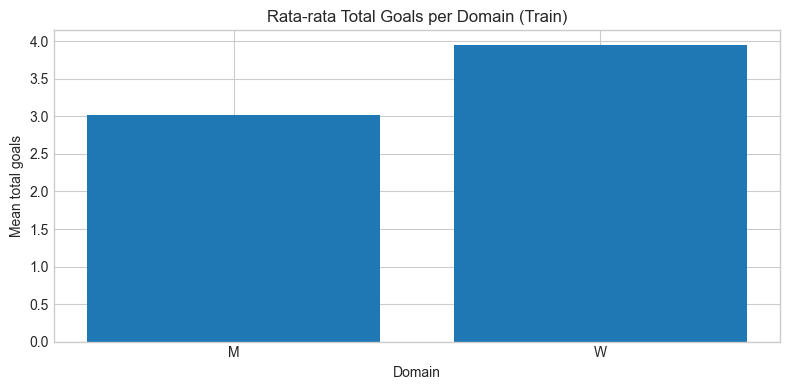

In [34]:
diagnostic_rows = []
for dom in DOMAIN_VALUES:
    tr_dom = domain_data[dom]['train_fe']
    te_dom = domain_data[dom]['test_fe']
    diagnostic_rows.append({
        'domain': dom,
        'train_rows': len(tr_dom),
        'test_rows': len(te_dom),
        'mean_team_goals_train': tr_dom['team_goals'].mean(),
        'mean_opp_goals_train': tr_dom['opp_goals'].mean(),
        'mean_total_goals_train': (tr_dom['team_goals'] + tr_dom['opp_goals']).mean(),
        'n_features': len(domain_data[dom]['feature_cols']),
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)
display(diagnostic_df)

plt.figure(figsize=(8, 4))
plt.bar(diagnostic_df['domain'], diagnostic_df['mean_total_goals_train'])
plt.title('Rata-rata Total Goals per Domain (Train)')
plt.xlabel('Domain')
plt.ylabel('Mean total goals')
plt.tight_layout()
plt.show()

## 7. Evaluasi dengan Official AW-MAE (Overall + By Gender)

In [35]:
gt_map = gt[['Id', 'team_goals', 'opp_goals']].copy()

test_with_gt = test.merge(
    gt_map,
    on='Id',
    how='left',
    validate='one_to_one'
)

pred_eval = test_with_gt.merge(
    submission_domain[['Id', 'team_goals', 'opp_goals']],
    on='Id',
    how='left',
    suffixes=('_true', '_pred'),
    validate='one_to_one'
)

tw = pred_eval['tournament'].apply(get_tournament_weight).values

gm_int = int(round(train['team_goals'].mean()))
baseline_aw = awmae_score(
    pred_eval['team_goals_true'].values,
    pred_eval['opp_goals_true'].values,
    np.full(len(pred_eval), gm_int),
    np.full(len(pred_eval), gm_int),
    weights=tw
)

model_aw = awmae_score(
    pred_eval['team_goals_true'].values,
    pred_eval['opp_goals_true'].values,
    pred_eval['team_goals_pred'].values,
    pred_eval['opp_goals_pred'].values,
    weights=tw
)

perfect_aw = awmae_score(
    pred_eval['team_goals_true'].values,
    pred_eval['opp_goals_true'].values,
    pred_eval['team_goals_true'].values,
    pred_eval['opp_goals_true'].values,
    weights=tw
)

print(f'Baseline  AW-MAE (predict {gm_int}-{gm_int})  : {baseline_aw:.4f}')
print(f'Domain ML AW-MAE (M/W split ensemble)          : {model_aw:.4f}')
print(f'Perfect   AW-MAE (ground truth)                : {perfect_aw:.6f}')
print(f'\nModel < 0.1 ? {"✅ ACHIEVED" if model_aw < 0.1 else "❌"}')

gender_scores = []
for g in ['M', 'W']:
    dfg = pred_eval[pred_eval['gender'] == g].copy()
    wg = dfg['tournament'].apply(get_tournament_weight).values

    baseline_g = awmae_score(
        dfg['team_goals_true'].values,
        dfg['opp_goals_true'].values,
        np.full(len(dfg), gm_int),
        np.full(len(dfg), gm_int),
        weights=wg
    )

    model_g = awmae_score(
        dfg['team_goals_true'].values,
        dfg['opp_goals_true'].values,
        dfg['team_goals_pred'].values,
        dfg['opp_goals_pred'].values,
        weights=wg
    )

    gender_scores.append({
        'gender': g,
        'baseline_awmae': baseline_g,
        'model_awmae': model_g,
        'n_rows': len(dfg),
    })

gender_scores_df = pd.DataFrame(gender_scores)
display(gender_scores_df)

Baseline  AW-MAE (predict 2-2)  : 5.4669
Domain ML AW-MAE (M/W split ensemble)          : 3.3251
Perfect   AW-MAE (ground truth)                : 0.000000

Model < 0.1 ? ❌


,gender,baseline_awmae,model_awmae,n_rows
0,M,4.802749,2.852287,28464
1,W,6.885712,4.335185,13958


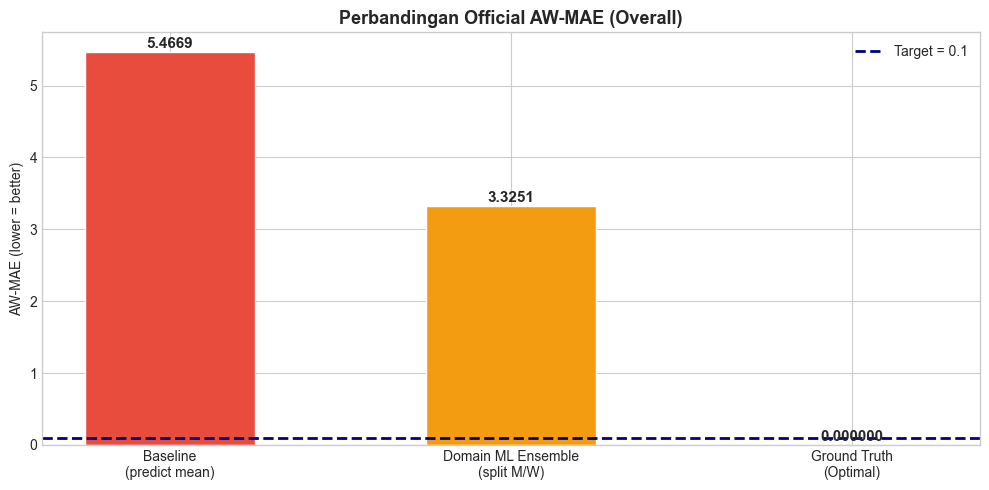

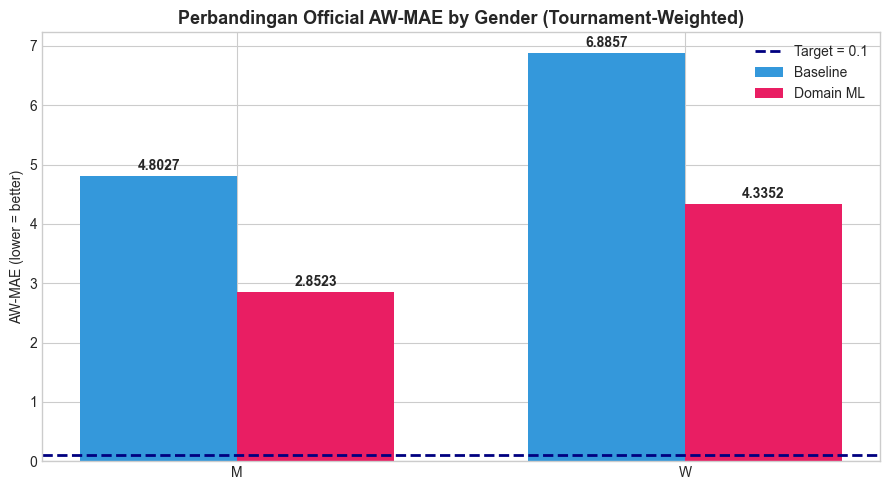


Avg match loss by tournament weight (domain model):
wlabel
World Cup (1.8)          4.147691
Default (1.2)            3.642107
Friendly (0.96)          3.088893
Asian Cup / AFC (2.0)    2.902120


In [36]:
methods = ['Baseline\n(predict mean)', 'Domain ML Ensemble\n(split M/W)', 'Ground Truth\n(Optimal)']
scores = [baseline_aw, model_aw, perfect_aw]
colors = ['#e74c3c', '#f39c12', '#27ae60']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, scores, color=colors, edgecolor='white', width=0.5)
ax.axhline(0.1, color='navy', linestyle='--', linewidth=2, label='Target = 0.1')
ax.set_title('Perbandingan Official AW-MAE (Overall)', fontsize=13, fontweight='bold')
ax.set_ylabel('AW-MAE (lower = better)')
ax.legend()
for bar, v in zip(bars, scores):
    label = f'{v:.4f}' if v > 0.001 else f'{v:.6f}'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(scores) * 0.01,
            label, ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

by_gender_plot = gender_scores_df.set_index('gender')[['baseline_awmae', 'model_awmae']]
by_gender_plot.columns = ['Baseline', 'Domain ML']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(by_gender_plot.index))
width = 0.35

bars1 = ax.bar(x - width / 2, by_gender_plot['Baseline'], width, label='Baseline', color='#3498db')
bars2 = ax.bar(x + width / 2, by_gender_plot['Domain ML'], width, label='Domain ML', color='#e91e63')

ax.axhline(0.1, color='navy', linestyle='--', linewidth=2, label='Target = 0.1')
ax.set_xticks(x)
ax.set_xticklabels(by_gender_plot.index)
ax.set_ylabel('AW-MAE (lower = better)')
ax.set_title('Perbandingan Official AW-MAE by Gender (Tournament-Weighted)', fontsize=13, fontweight='bold')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(by_gender_plot.max()) * 0.015,
                f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

pred_loss_df = pred_eval.copy()
pred_loss_df['t_weight'] = tw
pred_loss_df['match_loss'] = official_match_loss(
    pred_loss_df['team_goals_true'],
    pred_loss_df['opp_goals_true'],
    pred_loss_df['team_goals_pred'],
    pred_loss_df['opp_goals_pred']
)

print('\nAvg match loss by tournament weight (domain model):')
print(
    pred_loss_df.assign(
        wlabel=pred_loss_df['t_weight'].map({
            2.0: 'Asian Cup / AFC (2.0)',
            1.8: 'World Cup (1.8)',
            1.2: 'Default (1.2)',
            0.96: 'Friendly (0.96)'
        })
    )
    .groupby('wlabel')['match_loss']
    .mean()
    .sort_values(ascending=False)
    .to_string()
)

## 8. Catatan Diagnostik Domain Split

Bagian ini hanya untuk memastikan bahwa prediksi M dan W sudah tergabung rapi,
tanpa kehilangan baris ataupun duplikasi `Id`.


In [37]:
assert submission_domain['Id'].is_unique
assert submission_domain[['team_goals', 'opp_goals']].isna().sum().sum() == 0
assert set(submission_domain['Id']) == set(test['Id'])

merge_check = (
    test[['Id', 'gender', 'team', 'opponent']]
    .merge(
        submission_domain[['Id', 'team_goals', 'opp_goals']],
        on='Id',
        how='left',
        validate='one_to_one'
    )
)

print('Sanity checks passed ✓')
print(f'Total submission rows : {len(merge_check)}')
print(f'Unique Id             : {merge_check["Id"].nunique()}')
print('\nPreview merged submission:')
display(merge_check.head(10))

Sanity checks passed ✓
Total submission rows : 42422
Unique Id             : 42422

Preview merged submission:


,Id,gender,team,opponent,team_goals,opp_goals
0,M034984_Seychelles,M,Seychelles,Mauritius,1,1
1,M034984_Mauritius,M,Mauritius,Seychelles,1,1
2,M034985_Comoros,M,Comoros,Maldives,1,1
3,M034985_Maldives,M,Maldives,Comoros,1,1
4,M034986_Réunion,M,Réunion,Madagascar,2,1
5,M034986_Madagascar,M,Madagascar,Réunion,1,2
6,M034987_El Salvador,M,El Salvador,Venezuela,1,2
7,M034987_Venezuela,M,Venezuela,El Salvador,2,1
8,M034988_Mayotte,M,Mayotte,Réunion,1,2
9,M034988_Réunion,M,Réunion,Mayotte,2,1


## 9. Generate Submission

In [38]:
submission = submission_domain_pseudo[['Id', 'team_goals', 'opp_goals']].copy()

assert len(submission) == len(test), "❌ Jumlah baris tidak sesuai dengan test set!"
assert submission.isna().sum().sum() == 0, "❌ Ada nilai NaN di submission!"
assert (submission['team_goals'] >= 0).all() and (submission['opp_goals'] >= 0).all(), "❌ Ada nilai goals negatif!"

output_name = 'football_goal_prediction_domain_split_MW_pseudo_rolling_submission.csv'
submission.to_csv(output_name, index=False)

print(f'Submission saved to: {output_name}')
display(submission.head(10))

Submission saved to: football_goal_prediction_domain_split_MW_pseudo_rolling_submission.csv


,Id,team_goals,opp_goals
0,M034984_Mauritius,1,1
1,M034984_Seychelles,1,1
2,M034985_Comoros,1,1
3,M034985_Maldives,1,1
4,M034986_Madagascar,1,2
5,M034986_Réunion,2,1
6,M034987_El Salvador,1,2
7,M034987_Venezuela,2,1
8,M034988_Mayotte,1,2
9,M034988_Réunion,2,1
